# Imports

In [4]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Path
from pathlib import Path

# HDF5
import h5py

# RegEx
import re

# Auxiliary Functions

In [5]:
def load_group(name, h5f):
    result = {}
    for k, v in h5f.get(name, {}).items():

        # Extract scalar or array
        val = v[()].item() if np.ndim(v[()]) == 0 else v[()]

        # Decode byte strings automatically
        if isinstance(val, bytes):
            val = val.decode('utf-8')

        # Save the result
        result[k] = val

    return result

# Single Line Plot - 1D

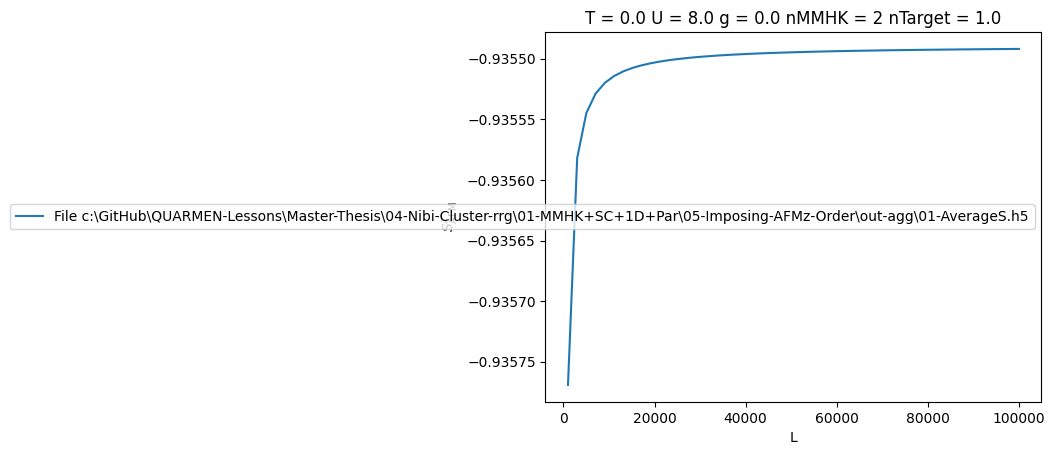

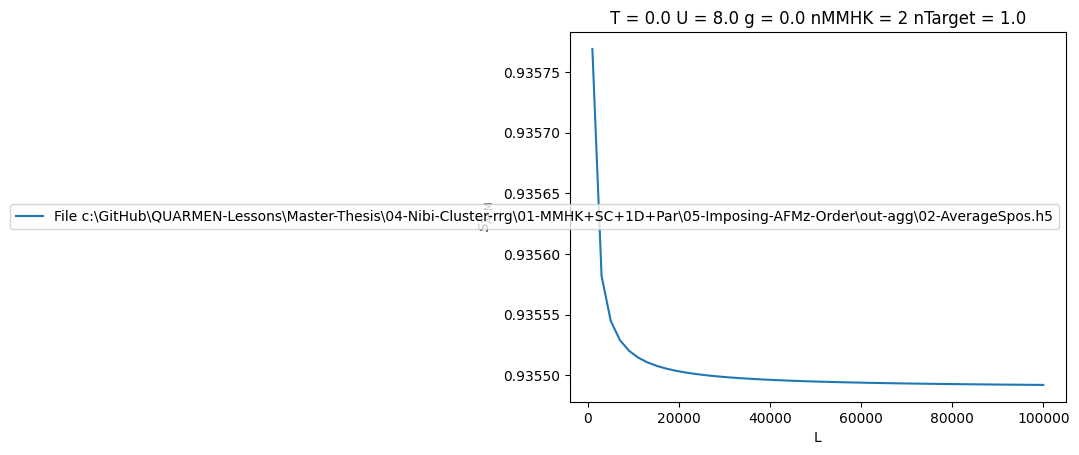

In [6]:
# File to read from
file_list = []

# Choose what to plot
x_name = "L"
y_name = "afm_z_sq"

# From where to read the data
x_source = "params"
y_source = "out"

# What to label the plot with
x_label = "L"
y_label = r"$S_\text{AFM}^z$"

# Apply a function to the outputs
yy_func = lambda x: x

# Parameters which should not go to the title of the plot
banned = ["mu_min", "mu_max", "mu_eps"]

# Get the directory where the script is located
current_dir = Path.cwd()

# Get the output directory
current_out = current_dir / "out-agg"


if len(file_list) == 0:
    file_list = current_out.iterdir()

for file_name in file_list:

    # Make arrays to store the data
    xx = []
    yy = []

    # Set of all possible keys
    params_last = dict()
    consts = []

    # Get the file path
    filepath = current_out / file_name

    # Create the figure
    plt.figure()

    # Open the aggregated HDF5 file
    with h5py.File(filepath, "r") as file:
        
        # Iterate through all top-level run groups
        for run_id in file.keys():
            run_group = file[run_id]
            
            params = load_group("params", run_group)
            output = load_group("out", run_group)

            x_data = params.get(x_name) if x_source == "params" else output.get(x_name)
            y_data = params.get(y_name) if y_source == "params" else output.get(y_name)

            if x_data is None or y_data is None:
                print(f"Warning: Missing data for {x_name} or {y_name} in {run_id} (skipping).")
                continue

            xx += [x_data]
            yy += [y_data]

            # Create the key list
            if len(params_last) == 0:
                params_last = params.copy()
                consts = list(params_last.keys())
                consts = [item for item in consts if item not in banned]
            
            # Eliminate keys whose values change
            else:
                for key in consts:
                    if params[key] != params_last[key]:
                        consts.remove(key)
            
            params_last = params.copy()


    # Plot title says which parameters were the same accross all runs
    plt.title(" ".join([f"{key} = {value}" for (key, value) in params_last.items() if key in consts]))

    # Convert the data
    xx = np.array(xx)
    yy = np.array(yy)

    # Sort the arrays by x
    sort_indices = np.argsort(xx)

    # View those arrays in the sorted order
    xx_sorted = xx[sort_indices]
    yy_sorted = yy[sort_indices]

    # Plot the data
    plt.plot(xx_sorted, yy_func(yy_sorted), label=f"File {file_name}", zorder=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.show()